<a href="https://colab.research.google.com/github/Chiranthan7/Breast-cancer-survival-prediction/blob/main/Brest_Cancer_Survival_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

sns.set()
plt.style.use('ggplot')

In [ ]:
df = pd.read_csv('/content/Breast_Cancer.csv')

In [ ]:
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


# DATA PREPROCESSING

In [ ]:
df['Status'].unique()

array(['Alive', 'Dead'], dtype=object)

In [ ]:
# M-> Malignint
# B-> Benign

In [ ]:
# Supervised-> target
# Unsupervised
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

# missing value

In [ ]:
df.isnull().sum()

,0
Age,0
Race,0
Marital Status,0
T Stage,0
N Stage,0
6th Stage,0
differentiate,0
Grade,0
A Stage,0
Tumor Size,0


<Axes: >

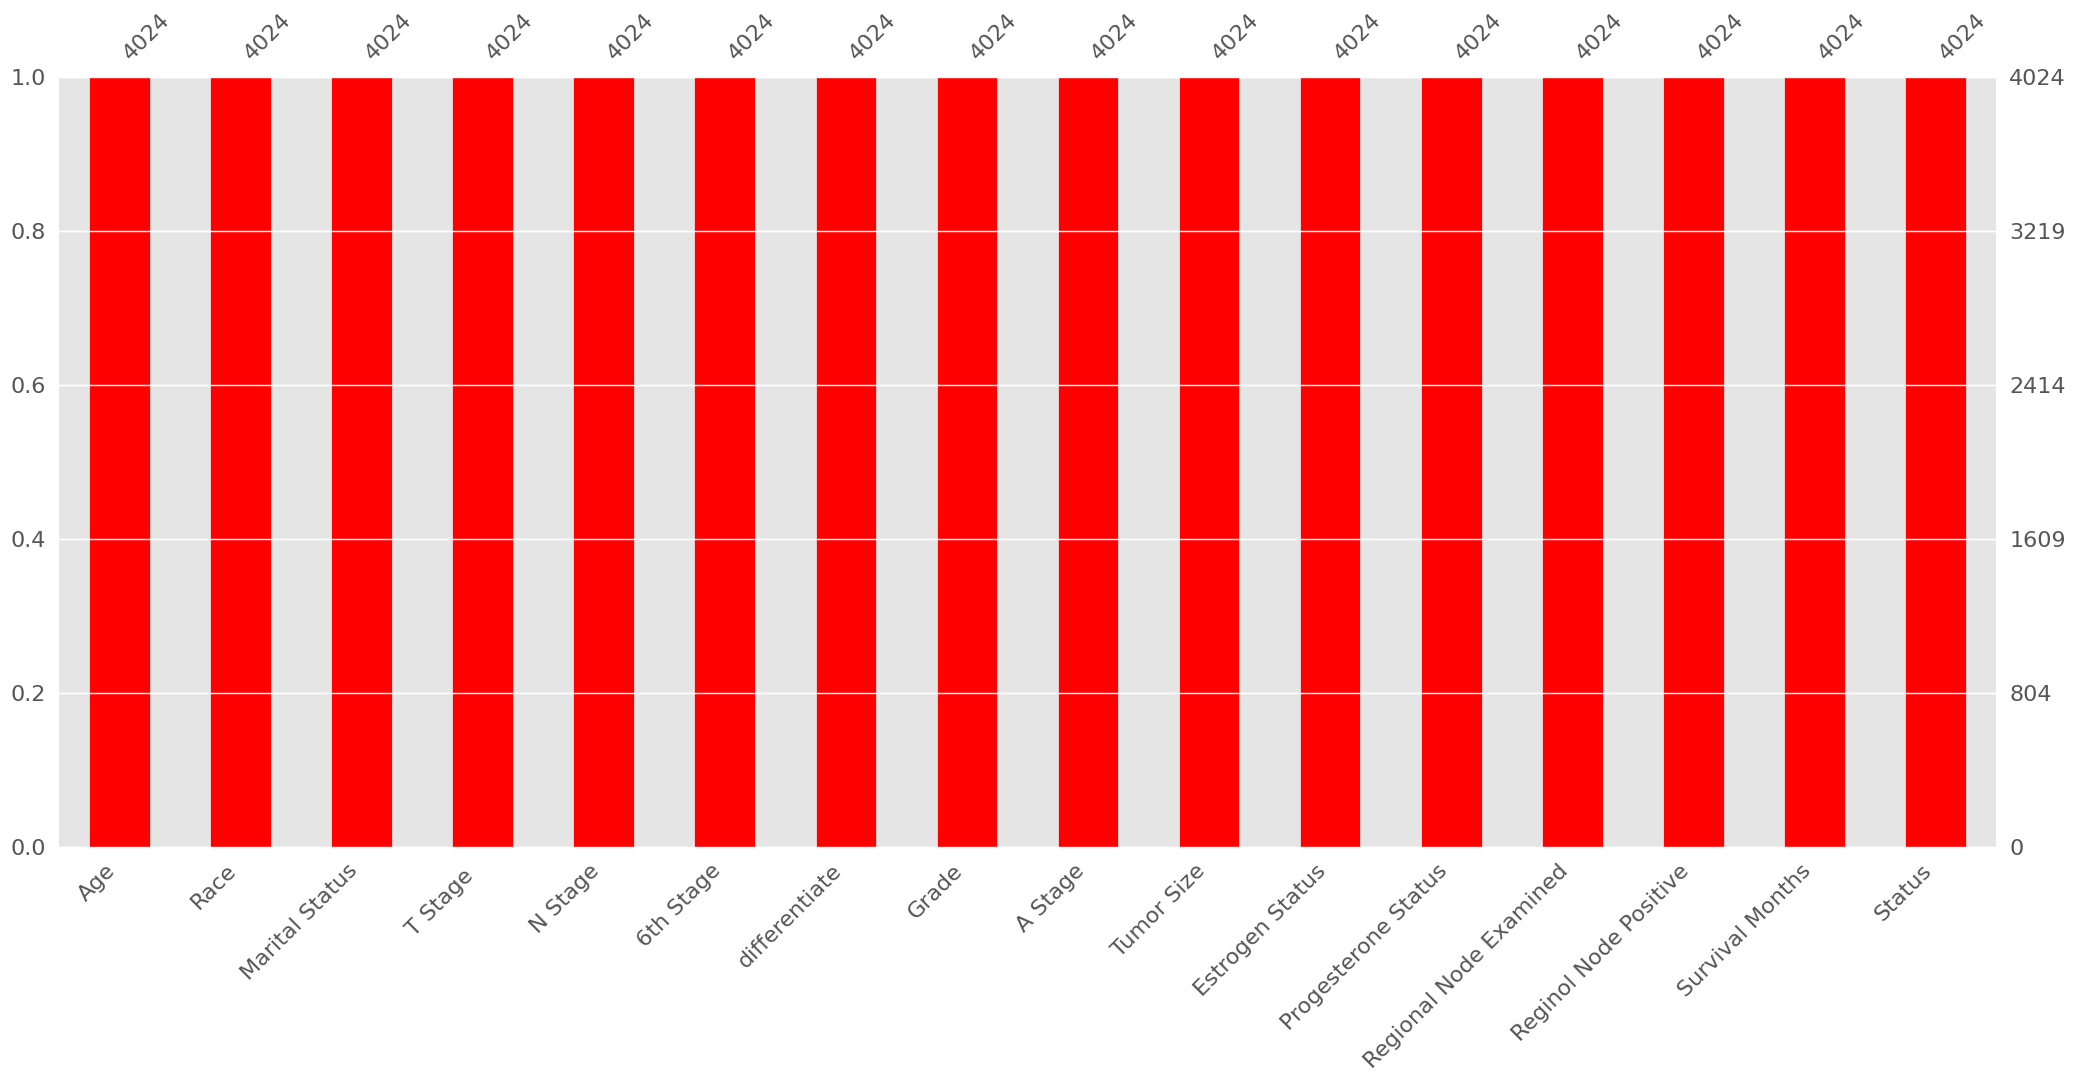

In [ ]:
msno.bar(df, color="red")

In [ ]:
# There are no missing value in the dataset

In [ ]:
df['Status'] = df['Status'].map({'Alive':0, 'Dead':1})

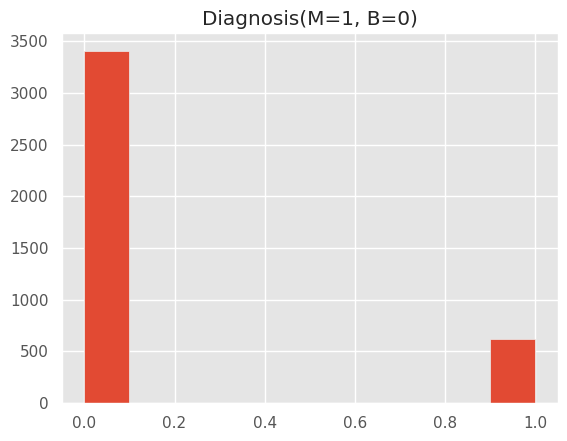

In [ ]:
plt.hist(df['Status'])
plt.title('Diagnosis(M=1, B=0)')
plt.show()

# EDA

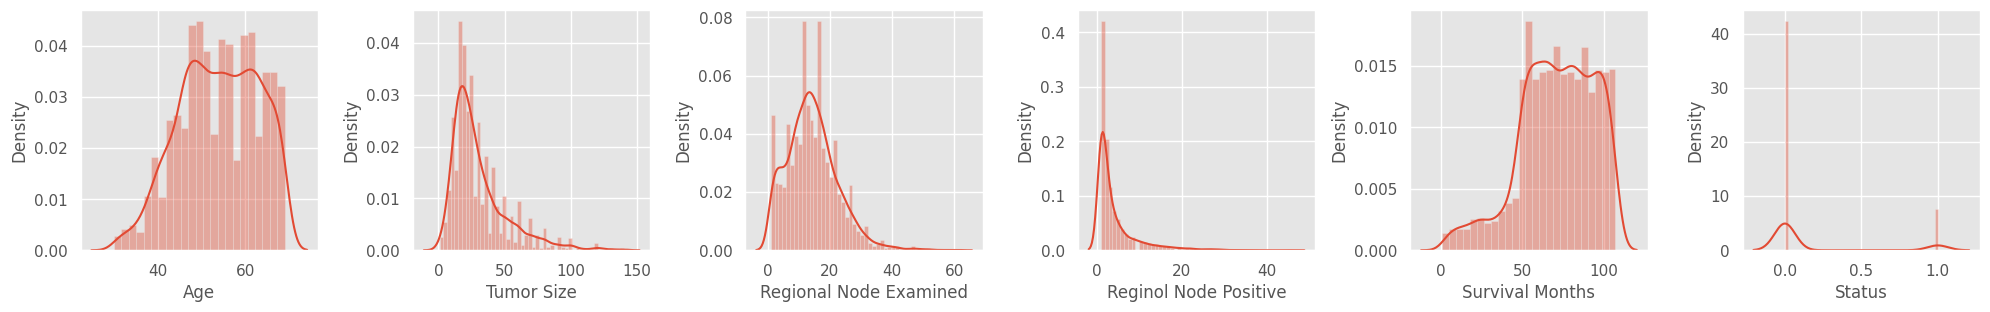

In [ ]:
# each 5 row its having 6 columns
# density graph

plt.figure(figsize=(20,15))
plotnumber=1
for column in df.select_dtypes(include=np.number).columns: # Iterate only over numerical columns
    if plotnumber<=30:
        ax = plt.subplot(5,6, plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column)
    plotnumber+=1

plt.tight_layout()
plt.show()

# CORR

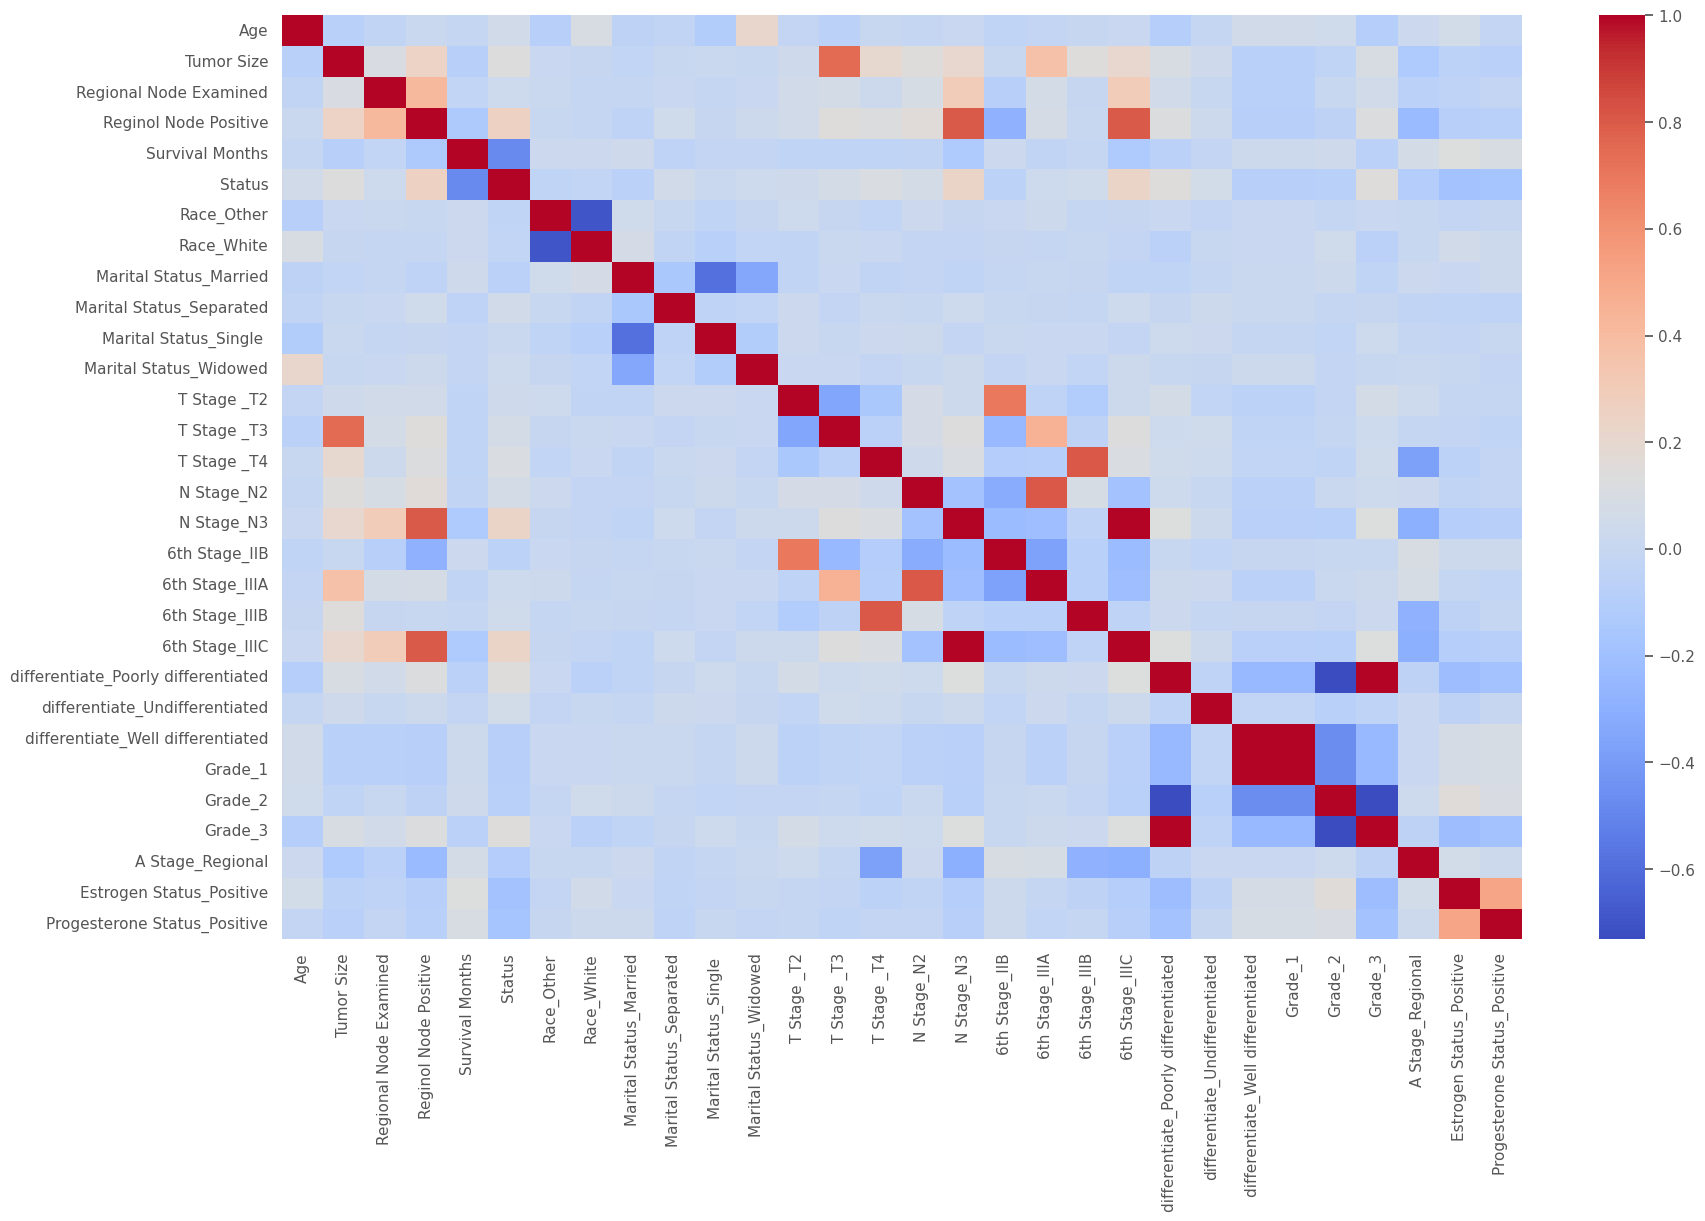

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

corr = df_encoded.corr()

plt.figure(figsize=(20,12))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [ ]:
df_encoded.corr()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months,Status,Race_Other,Race_White,Marital Status_Married,Marital Status_Separated,...,6th Stage_IIIC,differentiate_Poorly differentiated,differentiate_Undifferentiated,differentiate_Well differentiated,Grade_1,Grade_2,Grade_3,A Stage_Regional,Estrogen Status_Positive,Progesterone Status_Positive
Age,1.000000,-0.077215,-0.033345,0.012586,-0.009390,0.055921,-0.083334,0.094113,-0.051305,-0.028940,...,0.009664,-0.093476,-0.012730,0.058039,0.058039,0.046329,-0.093476,0.020860,0.059787,-0.021269
Tumor Size,-0.077215,1.000000,0.104352,0.242322,-0.086901,0.134205,0.007283,-0.005955,-0.028056,-0.001266,...,0.207786,0.097969,0.044634,-0.076851,-0.076851,-0.041800,0.097969,-0.123883,-0.059585,-0.069879
Regional Node Examined,-0.033345,0.104352,1.000000,0.411580,-0.022054,0.034772,0.012898,-0.008620,-0.009878,0.007275,...,0.297098,0.057535,0.000991,-0.081990,-0.081990,0.004510,0.057535,-0.069010,-0.044836,-0.018051
Reginol Node Positive,0.012586,0.242322,0.411580,1.000000,-0.135214,0.256638,0.002773,-0.012529,-0.042492,0.047595,...,0.802351,0.120495,0.026963,-0.084261,-0.084261,-0.054638,0.120495,-0.232849,-0.085985,-0.078069
Survival Months,-0.009390,-0.086901,-0.022054,-0.135214,1.000000,-0.476514,0.024674,0.022603,0.041143,-0.043556,...,-0.128512,-0.068664,-0.020667,0.028252,0.028252,0.045574,-0.068664,0.070109,0.128469,0.096018
Status,0.055921,0.134205,0.034772,0.256638,-0.476514,1.000000,-0.040780,-0.023977,-0.067734,0.053237,...,0.233250,0.143460,0.061328,-0.089132,-0.089132,-0.076873,0.143460,-0.096584,-0.184650,-0.177079
Race_Other,-0.083334,0.007283,0.012898,0.002773,0.024674,-0.040780,1.000000,-0.694684,0.051889,0.003681,...,-0.007236,0.011609,-0.020245,0.007579,0.007579,-0.012968,0.011609,0.001943,-0.020625,-0.006048
Race_White,0.094113,-0.005955,-0.008620,-0.012529,0.022603,-0.023977,-0.694684,1.000000,0.074839,-0.034028,...,-0.015779,-0.062434,-0.001162,0.009016,0.009016,0.050545,-0.062434,0.004776,0.053110,0.029292
Marital Status_Married,-0.051305,-0.028056,-0.009878,-0.042492,0.041143,-0.067734,0.051889,0.074839,1.000000,-0.147120,...,-0.037437,-0.037132,-0.011296,0.012796,0.012796,0.026383,-0.037132,0.022505,0.007716,0.026891
Marital Status_Separated,-0.028940,-0.001266,0.007275,0.047595,-0.043556,0.053237,0.003681,-0.034028,-0.147120,1.000000,...,0.034678,-0.002242,0.027149,0.013334,0.013334,-0.010985,-0.002242,-0.031167,-0.037770,-0.044902


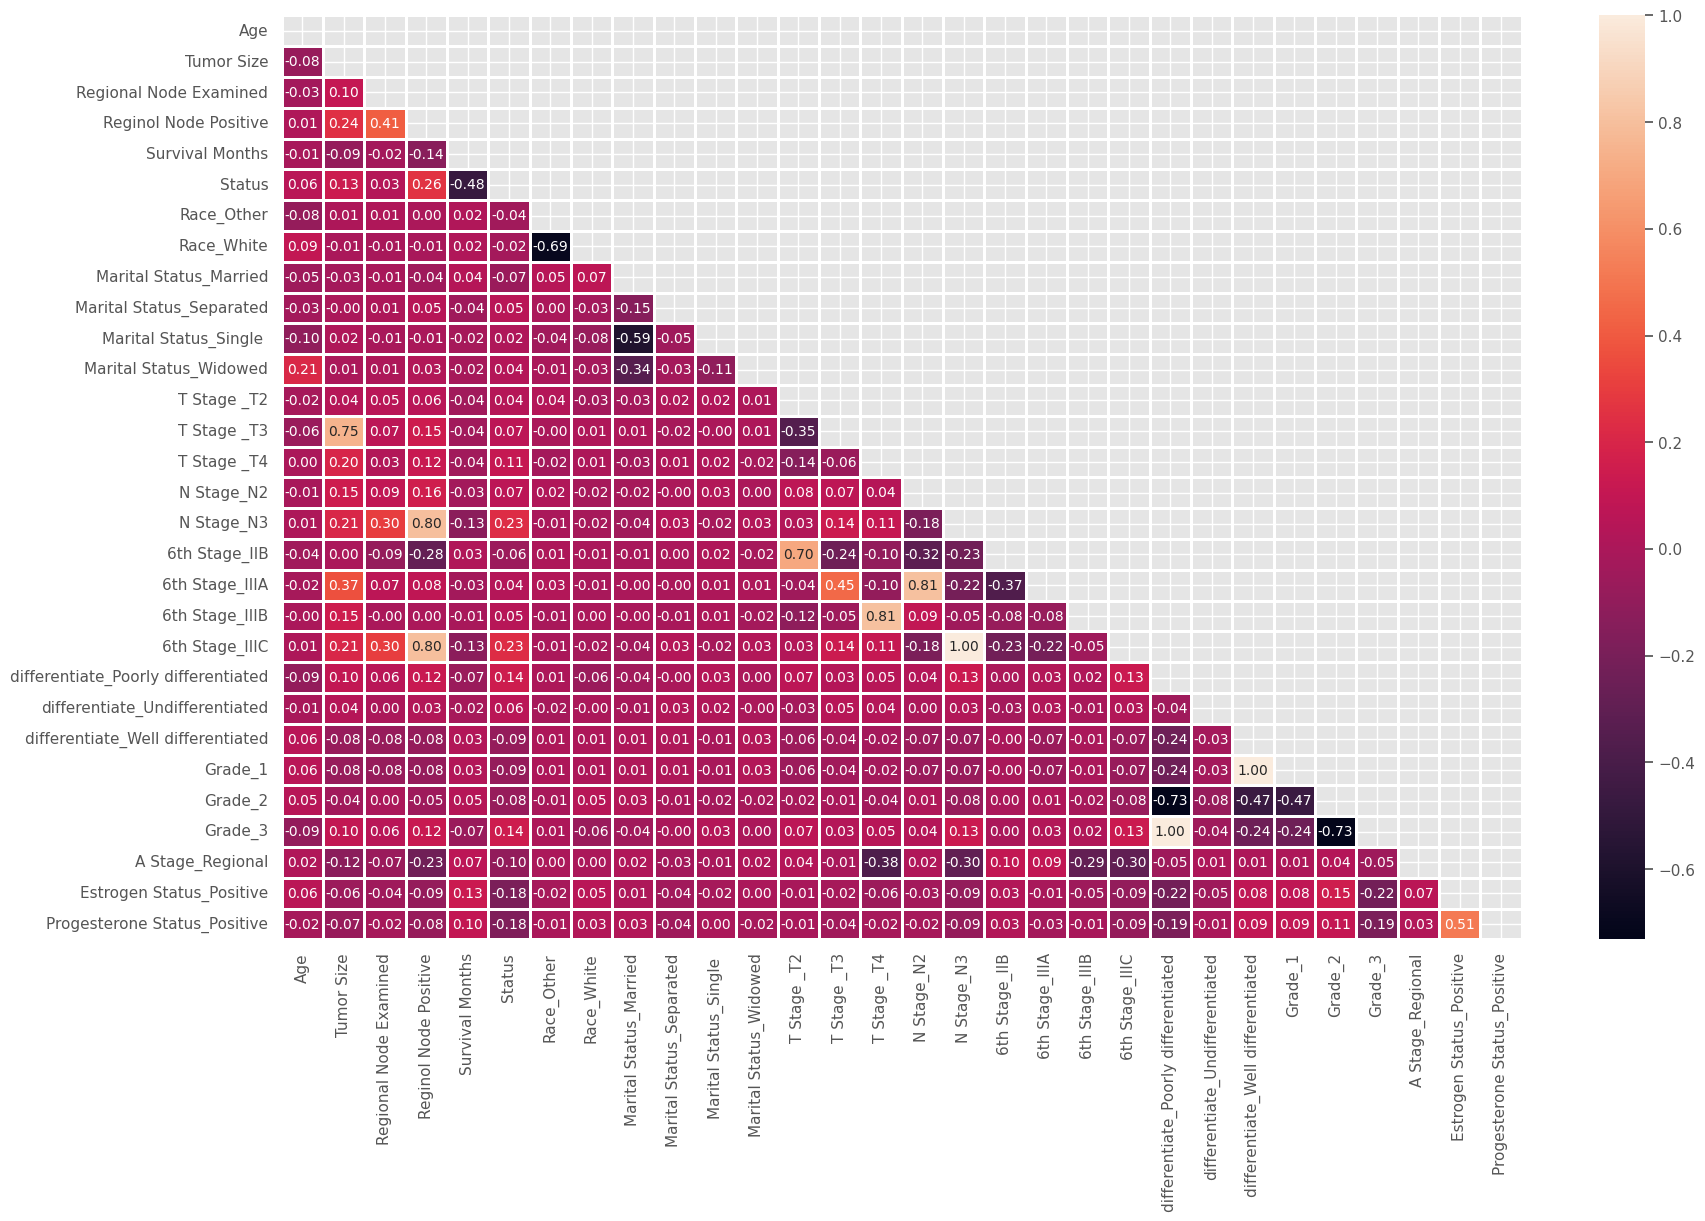

In [ ]:
# heatmap
plt.figure(figsize=(20,12))
corr=df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, linewidths=1, annot=True, fmt = ".2f")
plt.show()

In [ ]:
# highly correlated feature
# multicollinearity

In [ ]:
# feature selection
corr_matrix = df_encoded.corr().abs()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
tri_df = corr_matrix.mask(mask)

to_drop = [x for x in tri_df.columns if any(tri_df[x]>0.92)]

# Ensure 'Status' (the target variable) is not accidentally dropped if it appears in to_drop
if 'Status' in to_drop:
    to_drop.remove('Status')

df_selected_features = df_encoded.drop(to_drop, axis=1)

print(df_selected_features.shape[1])

27


In [ ]:
# df.drop('id', axis=1, inplace=True) # Commented out as 'id' column not found

In [ ]:
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [ ]:
# 32 feature reduce it 23 now

# Buliding Model

In [ ]:
X = df_selected_features.drop('Status', axis=1)
y = df_selected_features['Status']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train ,y_test =train_test_split(X,y, test_size=0.2, random_state=0)

In [ ]:
# scaling data
from sklearn.preprocessing import StandardScaler
import pandas as pd # Ensure pandas is imported

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Apply one-hot encoding
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - crucial for consistent feature sets between train and test after get_dummies
# This handles cases where a category might exist in train but not test, or vice-versa
train_cols = X_train.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0

X_test = X_test[train_cols] # Ensure X_test columns are in the same order as X_train

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train.shape

(3219, 15)

# Apply Machine learning Algo

#  LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = log_reg.predict(X_test)

In [ ]:
y_pred

array(['Alive', 'Dead', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Dead', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Dead', 'Alive',
       'Dead', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Dead', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Dead', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Dead', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Dead', 'Dead', 'Alive', 'Alive',
       'Alive', 'Alive', 'Dead', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Aliv

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, log_reg.predict(X_train)))
log_reg_acc = accuracy_score(y_test, log_reg.predict(X_test))
print(log_reg_acc)
y_pred = log_reg.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.895309102205654
0.8919254658385093
[[669  12]
 [ 75  49]]
              precision    recall  f1-score   support

       Alive       0.90      0.98      0.94       681
        Dead       0.80      0.40      0.53       124

    accuracy                           0.89       805
   macro avg       0.85      0.69      0.73       805
weighted avg       0.88      0.89      0.88       805



# KNN

In [ ]:

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test)

In [ ]:
y_pred

array(['Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Dead', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Dead', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Dead', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Dead', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Dead', 'Dead', 'Alive', 'Alive',
       'Alive', 'Alive', 'Dead', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'D

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, knn.predict(X_train)))
knn_acc = accuracy_score(y_test, knn.predict(X_test))
print(knn_acc)
y_pred = knn.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8949984467225847
0.8546583850931677
[[662  19]
 [ 98  26]]
              precision    recall  f1-score   support

       Alive       0.87      0.97      0.92       681
        Dead       0.58      0.21      0.31       124

    accuracy                           0.85       805
   macro avg       0.72      0.59      0.61       805
weighted avg       0.83      0.85      0.82       805



# SVC

In [ ]:

#Hyperparameter tuning
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc= SVC(probability=True)

parameters = {
    'gamma': [0.0001, 0.001, 0.01, 0.1],
    'C':[0.01, 0.05, 0.5, 0.1, 1,10, 15,20]
}
grid_search = GridSearchCV(svc, parameters)
grid_search.fit(X_train, y_train)

GridSearchCV(estimator=SVC(probability=True),
             param_grid={'C': [0.01, 0.05, 0.5, 0.1, 1, 10, 15, 20],
                         'gamma': [0.0001, 0.001, 0.01, 0.1]})

In [ ]:
grid_search.best_params_

{'C': 20, 'gamma': 0.001}

In [ ]:
grid_search.best_score_

np.float64(0.8887870328332834)

In [ ]:
svc = SVC(C=15, gamma=0.01, probability=True)
svc.fit(X_train, y_train)

SVC(C=15, gamma=0.01, probability=True)

In [ ]:
y_pred = svc.predict(X_test)

In [ ]:
y_pred

array(['Dead', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Dead', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Dead', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Dead', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Dead', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Alive', 'Dead', 'Alive', 'Alive',
       'Dead', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Alive', 'Dead', 'Dead', 'Alive', 'Alive',
       'Alive', 'Alive', 'Dead', 'Alive', 'Alive', 'Alive', 'Alive',
       'Alive', 'Alive', 'Dead

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, svc.predict(X_train)))
svc_acc = accuracy_score(y_test, svc.predict(X_test))
print(svc_acc)
y_pred = svc.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9148803976390183
0.8906832298136645
[[668  13]
 [ 75  49]]
              precision    recall  f1-score   support

       Alive       0.90      0.98      0.94       681
        Dead       0.79      0.40      0.53       124

    accuracy                           0.89       805
   macro avg       0.84      0.69      0.73       805
weighted avg       0.88      0.89      0.87       805



# DT

In [ ]:

from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()

parameters = {
    'criterion':['gini','entropy'],
    'max_depth':range(2,32,1),
    'min_samples_leaf':range(1,10,1),
    'min_samples_split':range(2,10,1),
    'splitter':['best','random']
}

grid_search_dt = GridSearchCV(dtc, parameters, cv=5, n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train, y_train)

Fitting 5 folds for each of 8640 candidates, totalling 43200 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(2, 32),
                         'min_samples_leaf': range(1, 10),
                         'min_samples_split': range(2, 10),
                         'splitter': ['best', 'random']},
             verbose=1)

In [ ]:
grid_search_dt.best_params_

{'criterion': 'gini',
 'max_depth': 25,
 'min_samples_leaf': 9,
 'min_samples_split': 5,
 'splitter': 'random'}

In [ ]:
grid_search_dt.best_score_

np.float64(0.9052524559759668)

In [ ]:
dtc = DecisionTreeClassifier(criterion='entropy', max_depth=15, min_samples_leaf=4, min_samples_split=5, splitter = 'random')

In [ ]:
dtc.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=15, min_samples_leaf=4,
                       min_samples_split=5, splitter='random')

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, dtc.predict(X_train)))
dtc_acc = accuracy_score(y_test, dtc.predict(X_test))
print(dtc_acc)
y_pred = dtc.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9242000621310966
0.8757763975155279
[[654  27]
 [ 73  51]]
              precision    recall  f1-score   support

       Alive       0.90      0.96      0.93       681
        Dead       0.65      0.41      0.50       124

    accuracy                           0.88       805
   macro avg       0.78      0.69      0.72       805
weighted avg       0.86      0.88      0.86       805



# RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rand_clf = RandomForestClassifier(criterion = 'entropy', max_depth = 10, max_features = 0.5, min_samples_leaf = 2, min_samples_split = 3, n_estimators = 130)
rand_clf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=10, max_features=0.5,
                       min_samples_leaf=2, min_samples_split=3,
                       n_estimators=130)

In [ ]:
y_pred = rand_clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, rand_clf.predict(X_train)))
rand_clf_acc = accuracy_score(y_test, rand_clf.predict(X_test))
print(rand_clf_acc)
y_pred = rand_clf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9431500465983225
0.901863354037267
[[668  13]
 [ 66  58]]
              precision    recall  f1-score   support

       Alive       0.91      0.98      0.94       681
        Dead       0.82      0.47      0.59       124

    accuracy                           0.90       805
   macro avg       0.86      0.72      0.77       805
weighted avg       0.90      0.90      0.89       805



In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.9065566577052625


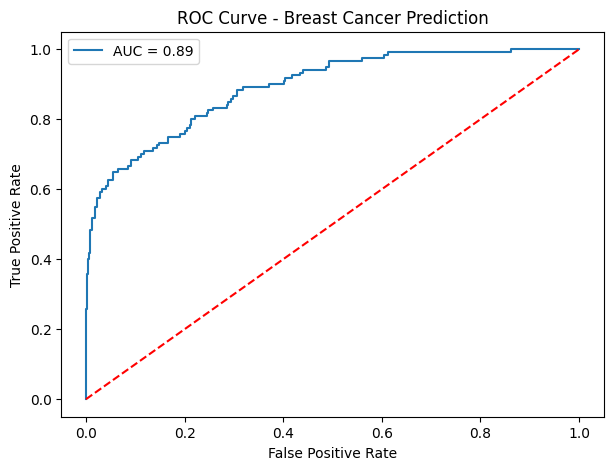

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf_model.predict_proba(X_test_df)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Breast Cancer Prediction")
plt.legend()

plt.show()

# GradientBoostingClassifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier()

parameters = {
    'loss': ['deviance', 'exponential'],
    'learning_rate': [0.001, 0.1],
    'n_estimators': [100, 150, 180]
}

grid_search_gbc = GridSearchCV(gbc, parameters, cv = 2, n_jobs = -5, verbose = 1)
grid_search_gbc.fit(X_train, y_train)

Fitting 2 folds for each of 12 candidates, totalling 24 fits


GridSearchCV(cv=2, estimator=GradientBoostingClassifier(), n_jobs=-5,
             param_grid={'learning_rate': [0.001, 0.1],
                         'loss': ['deviance', 'exponential'],
                         'n_estimators': [100, 150, 180]},
             verbose=1)

In [ ]:
grid_search_gbc.best_params_

{'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 100}

In [ ]:
grid_search_gbc.best_score_

np.float64(0.9049434662940216)

In [ ]:
gbc = GradientBoostingClassifier(learning_rate = 0.1, loss = 'exponential', n_estimators = 180)
gbc.fit(X_train, y_train)

GradientBoostingClassifier(loss='exponential', n_estimators=180)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, gbc.predict(X_train)))
gbc_acc = accuracy_score(y_test, gbc.predict(X_test))
print(gbc_acc)
y_pred = gbc.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9310344827586207
0.8968944099378882
[[663  18]
 [ 65  59]]
              precision    recall  f1-score   support

       Alive       0.91      0.97      0.94       681
        Dead       0.77      0.48      0.59       124

    accuracy                           0.90       805
   macro avg       0.84      0.72      0.76       805
weighted avg       0.89      0.90      0.89       805



#  XGBClassifier

In [ ]:
from xgboost import XGBClassifier
import pandas as pd # Import pandas for Series operations

xgb = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.01, max_depth = 5, n_estimators = 180)

# Convert y_train to numerical labels
y_train_encoded = y_train.map({'Alive': 0, 'Dead': 1})

xgb.fit(X_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=180,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_test_encoded = y_test.map({'Alive': 0, 'Dead': 1})

print(accuracy_score(y_train_encoded, xgb.predict(X_train)))
xgb_acc = accuracy_score(y_test_encoded, xgb.predict(X_test))
print(xgb_acc)
y_pred = xgb.predict(X_test)
print(confusion_matrix(y_test_encoded, y_pred))
print(classification_report(y_test_encoded, y_pred))

0.9195402298850575
0.9006211180124224
[[671  10]
 [ 70  54]]
              precision    recall  f1-score   support

           0       0.91      0.99      0.94       681
           1       0.84      0.44      0.57       124

    accuracy                           0.90       805
   macro avg       0.87      0.71      0.76       805
weighted avg       0.90      0.90      0.89       805



In [ ]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree Classifier', 'Random Forest Classifier', 'Gradient Boosting Classifier', 'XgBoost'],
    'Score': [100*round(log_reg_acc,4), 100*round(knn_acc,4), 100*round(svc_acc,4), 100*round(dtc_acc,4), 100*round(rand_clf_acc,4),
              100*round(gbc_acc,4), 100*round(xgb_acc,4)]
})
models.sort_values(by = 'Score', ascending = False)

,Model,Score
4,Random Forest Classifier,90.19
6,XgBoost,90.06
5,Gradient Boosting Classifier,89.69
0,Logistic Regression,89.19
2,SVM,89.07
3,Decision Tree Classifier,87.58
1,KNN,85.47


In [ ]:
import pickle
model = svc
pickle.dump(model, open("brest_cancer.pkl","wb"))

# Model Comparison

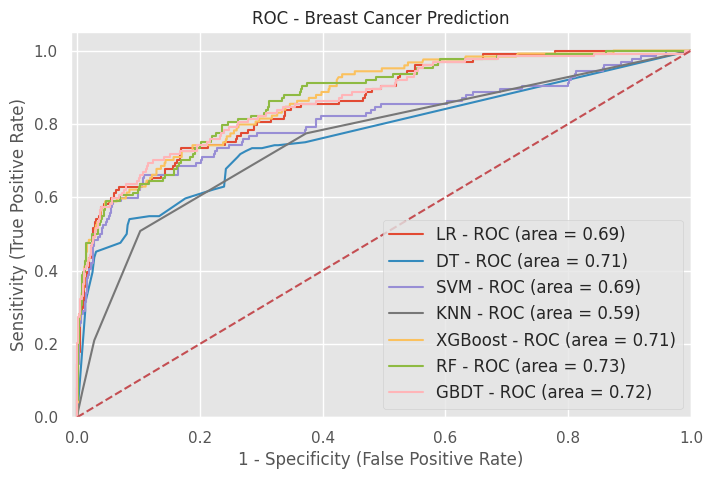

In [ ]:
from sklearn import metrics
plt.figure(figsize=(8,5))
models = [
{
    'label': 'LR',
    'model': log_reg,
},
{
    'label': 'DT',
    'model': dtc,
},
{
    'label': 'SVM',
    'model': svc,
},
{
    'label': 'KNN',
    'model': knn,
},
{
    'label': 'XGBoost',
    'model': xgb,
},
{
    'label': 'RF',
    'model': rand_clf,
},
{
    'label': 'GBDT',
    'model': gbc,
}
]

y_test_encoded = y_test.map({'Alive': 0, 'Dead': 1}) # Ensure y_test is encoded for ROC curve
y_train_encoded_for_fit = y_train.map({'Alive': 0, 'Dead': 1}) # Create encoded y_train for fitting

for m in models:
    model = m['model']

    # Fit all models with numerically encoded y_train
    model.fit(X_train, y_train_encoded_for_fit)

    # Ensure prediction for ROC curve is done with the correct target variable format
    # and explicitly set pos_label for binary classification where appropriate
    fpr1, tpr1, thresholds = metrics.roc_curve(y_test_encoded, model.predict_proba(X_test)[:,1], pos_label=1)
    # Remove pos_label from roc_auc_score as it's not a valid argument for binary y_true
    auc = metrics.roc_auc_score(y_test_encoded, model.predict(X_test))
    plt.plot(fpr1, tpr1, label='%s - ROC (area = %0.2f)' % (m['label'], auc))

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('ROC - Breast Cancer Prediction', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.savefig("roc_breast_cancer.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()

[89.19, 87.58, 89.07000000000001, 85.47, 90.06, 90.19, 89.69]
[np.float64(68.88), np.float64(68.77), np.float64(68.8), np.float64(59.089999999999996), np.float64(71.04), np.float64(72.91), np.float64(72.87)]


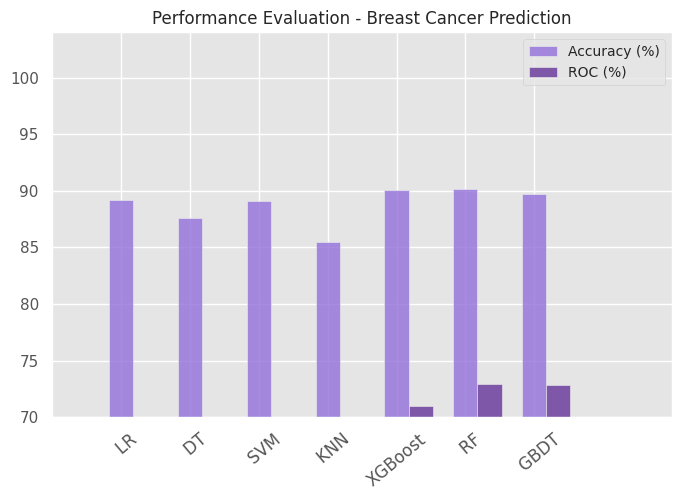

In [ ]:
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
models = [
{
    'label': 'LR',
    'model': log_reg,
},
{
    'label': 'DT',
    'model': dtc,
},
{
    'label': 'SVM',
    'model': svc,
},
{
    'label': 'KNN',
    'model': knn,
},
{
    'label': 'XGBoost',
    'model': xgb,
},
{
    'label': 'RF',
    'model': rand_clf,
},
{
    'label': 'GBDT',
    'model': gbc,
}
]

means_roc = []
means_accuracy = [100*round(log_reg_acc,4), 100*round(dtc_acc,4), 100*round(svc_acc,4), 100*round(knn_acc,4), 100*round(xgb_acc,4),
                  100*round(rand_clf_acc,4), 100*round(gbc_acc,4)]

y_test_encoded = y_test.map({'Alive': 0, 'Dead': 1})
y_train_encoded_for_fit = y_train.map({'Alive': 0, 'Dead': 1})

for m in models:
    model = m['model']
    model.fit(X_train, y_train_encoded_for_fit)
    y_pred=model.predict(X_test)
    fpr1, tpr1, thresholds = metrics.roc_curve(y_test_encoded, model.predict_proba(X_test)[:,1], pos_label=1)
    auc = metrics.roc_auc_score(y_test_encoded, model.predict(X_test))
    auc = 100*round(auc,4)
    means_roc.append(auc)

print(means_accuracy)
print(means_roc)

# data to plot
n_groups = 7
means_accuracy = tuple(means_accuracy)
means_roc = tuple(means_roc)

# create plot
fig, ax = plt.subplots(figsize=(8,5))
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

rects1 = plt.bar(index, means_accuracy, bar_width,
alpha=opacity,
color='mediumpurple',
label='Accuracy (%)')

rects2 = plt.bar(index + bar_width, means_roc, bar_width,
alpha=opacity,
color='rebeccapurple',
label='ROC (%)')

plt.xlim([-1, 8])
plt.ylim([70, 104])

plt.title('Performance Evaluation - Breast Cancer Prediction', fontsize=12)
plt.xticks(index, ('   LR', '   DT', '   SVM', '   KNN', 'XGBoost' , '   RF', '   GBDT'), rotation=40, ha='center', fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.savefig("PE_breast_cancer.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()

# Stacking Ensemble

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Base models
estimators = [
    ('lr', LogisticRegression()),
    ('knn', KNeighborsClassifier()),
    ('svc', SVC(C=15, gamma=0.01, probability=True)),
    ('rf', RandomForestClassifier(criterion='entropy', max_depth=10, max_features=0.5,
                                  min_samples_leaf=2, min_samples_split=3, n_estimators=130)),
    ('gbc', GradientBoostingClassifier(learning_rate=0.1, n_estimators=100))
]

# Meta-model
stack_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

# Train
stack_model.fit(X_train, y_train)

# Predict
y_pred_stack = stack_model.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))
print(confusion_matrix(y_test, y_pred_stack))
print(classification_report(y_test, y_pred_stack))


Stacking Accuracy: 0.9031055900621118
[[670  11]
 [ 67  57]]
              precision    recall  f1-score   support

       Alive       0.91      0.98      0.94       681
        Dead       0.84      0.46      0.59       124

    accuracy                           0.90       805
   macro avg       0.87      0.72      0.77       805
weighted avg       0.90      0.90      0.89       805



# Voting Ensemble

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(estimators=estimators, voting='soft')  # or 'hard'
voting_model.fit(X_train, y_train)

y_pred_vote = voting_model.predict(X_test)
print("Voting Accuracy:", accuracy_score(y_test, y_pred_vote))


Voting Accuracy: 0.9031055900621118


In [ ]:
from itertools import combinations
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# List of your trained base models
base_models = [
    ('lr', log_reg),
    ('knn', knn),
    ('svc', svc),
    ('dt', dtc),
    ('rf', rand_clf),
    ('gb', gbc)
]

best_acc = 0
best_combo = None

# Try all combinations from 2 to 6 models
for r in range(2, len(base_models)+1):
    for combo in combinations(base_models, r):
        # Create stacking classifier with current combo
        stack = StackingClassifier(
            estimators=list(combo),
            final_estimator=LogisticRegression(),
            cv=5,
            n_jobs=-1,
            passthrough=True  # passes original features to meta-learner
        )
        stack.fit(X_train, y_train)
        acc = accuracy_score(y_test, stack.predict(X_test))

        # Update best accuracy and combo
        if acc > best_acc:
            best_acc = acc
            best_combo = combo

# Display results
print(f"Best Accuracy: {best_acc}")
print("Best Model Combination:")
for name, model in best_combo:
    print("-", name)


Best Accuracy: 0.9080745341614906
Best Model Combination:
- dt
- rf
- gb


# ==========================================
# PCA Visualization
# ==========================================


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


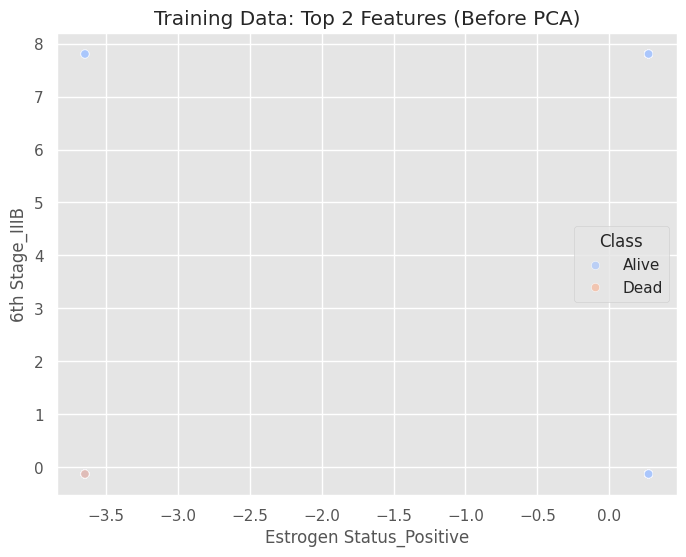

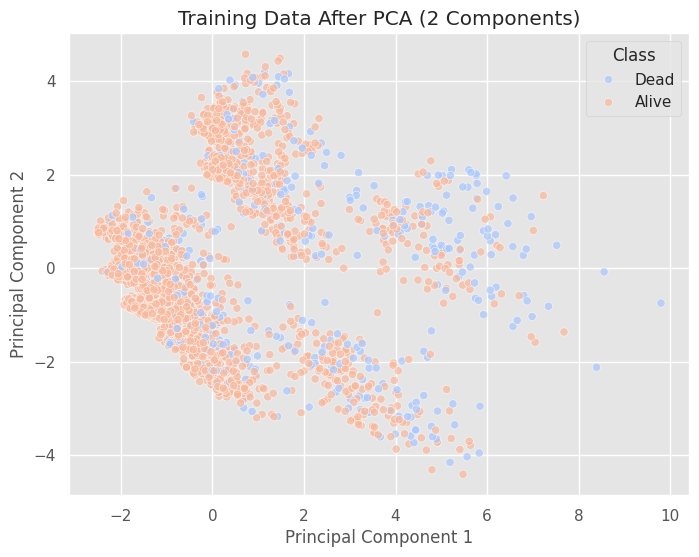

In [ ]:

# X_train and X_test are already scaled NumPy arrays from the previous cell.
# The error was in trying to create a DataFrame with mismatched column names.
# We need to correctly derive the column names for the one-hot encoded data.

# 1. Re-generate the column names based on the original X DataFrame's categorical features.
# This ensures we get the same column names that X_train (ndarray) has.
temp_X_for_col_names = X.copy()
categorical_cols_for_dummies = temp_X_for_col_names.select_dtypes(include=['object']).columns
# Perform get_dummies to get the column names that were generated during preprocessing
dummy_df_for_cols = pd.get_dummies(temp_X_for_col_names, columns=categorical_cols_for_dummies, drop_first=True)
final_feature_columns = dummy_df_for_cols.columns

# 2. Create DataFrames from the already scaled X_train and X_test NumPy arrays
# using the correctly generated column names.
X_train_df = pd.DataFrame(X_train, columns=final_feature_columns)
X_test_df  = pd.DataFrame(X_test, columns=final_feature_columns)

# ----------------------------
# PCA transformation (2 components for visualization)
# Since X_train and X_test are already scaled NumPy arrays,
# we apply PCA directly to these DataFrames, which are derived from the scaled data.
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_df)
X_test_pca  = pca.transform(X_test_df)

# ----------------------------
# Scatter plot of training data (Before PCA)
#    Using top 2 features by variance for comparison
# Now X_train_df has the correct column names, so this part should work.
top2_features = X_train_df.var().sort_values(ascending=False).index[:2]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_train_df[top2_features[0]],
    y=X_train_df[top2_features[1]],
    hue=y_train,
    palette='coolwarm',
    alpha=0.7
)
plt.xlabel(top2_features[0])
plt.ylabel(top2_features[1])
plt.title('Training Data: Top 2 Features (Before PCA)')
plt.legend(title='Class')
plt.savefig('before_pca.png', dpi=300)
plt.show()




plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_train_pca[:,0],
    y=X_train_pca[:,1],
    hue=y_train,
    palette='coolwarm',
    alpha=0.7
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Training Data After PCA (2 Components)')
plt.legend(title='Class')
plt.savefig('after_pca.png', dpi=300)
plt.show()

# ----------------------------
#  Feature contributions to principal components
# ----------------------------


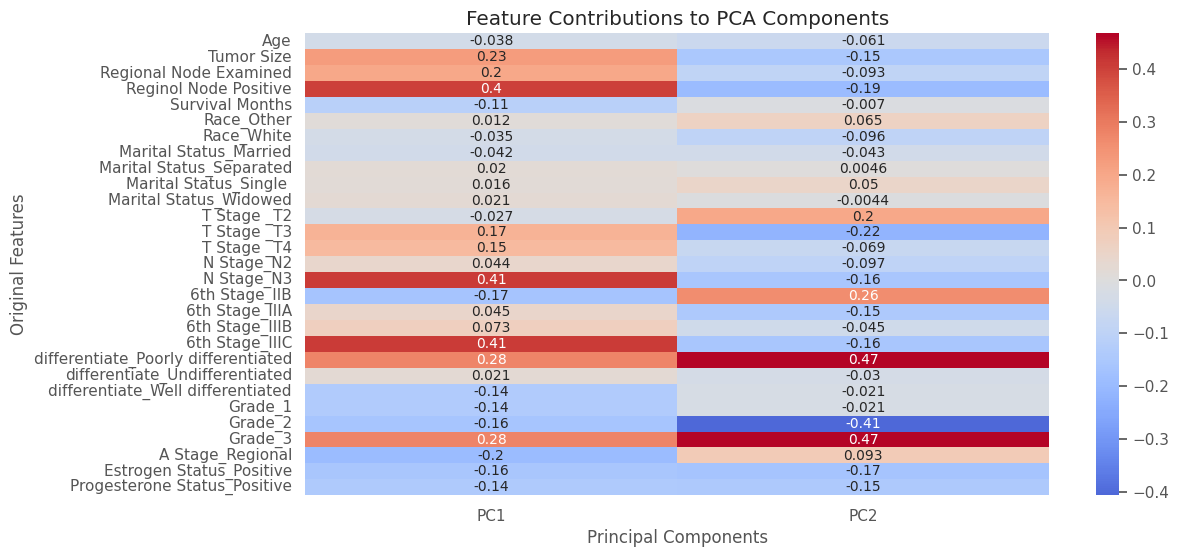

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=final_feature_columns
)

plt.figure(figsize=(12,6))
sns.heatmap(
    loadings,
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title('Feature Contributions to PCA Components')
plt.xlabel('Principal Components')
plt.ylabel('Original Features')
plt.savefig('pca_feature_contributions.png', dpi=300)
plt.show()

# ----------------------------
 # explained variance
# ----------------------------


In [ ]:
explained_variance = pd.DataFrame({
    'PC': ['PC1', 'PC2'],
    'Explained Variance (%)': pca.explained_variance_ratio_ * 100
})
print(explained_variance)


    PC  Explained Variance (%)
0  PC1               12.823550
1  PC2                9.101936


Stacking Accuracy: 0.9093167701863354
[[671  14]
 [ 59  61]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       685
           1       0.81      0.51      0.63       120

    accuracy                           0.91       805
   macro avg       0.87      0.74      0.79       805
weighted avg       0.90      0.91      0.90       805



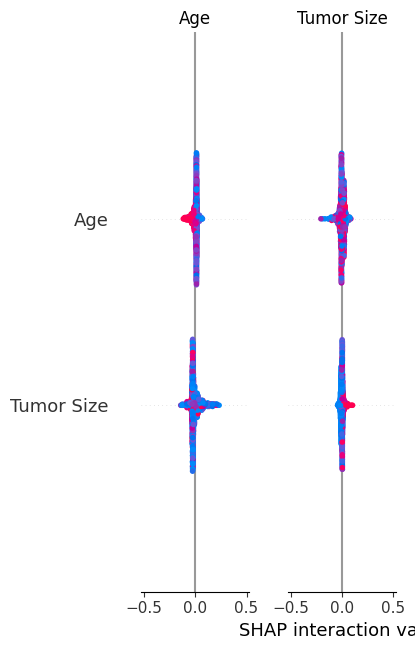

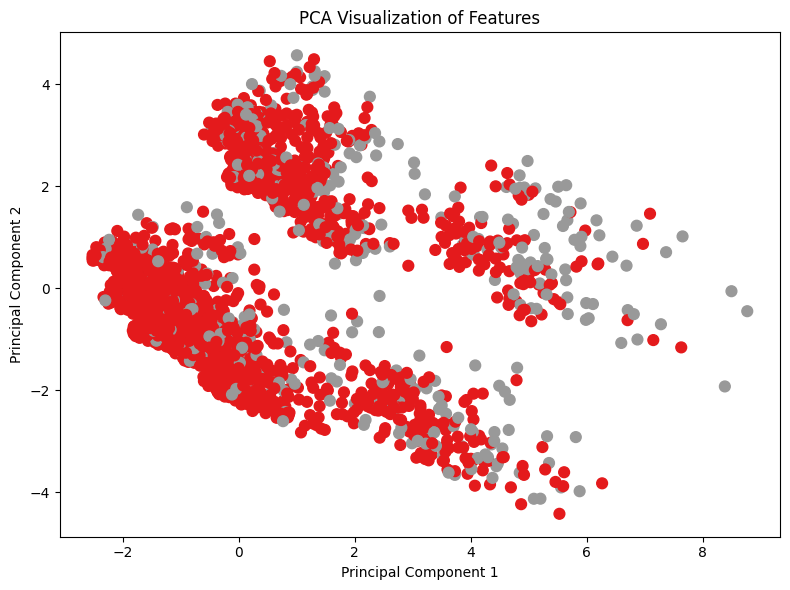

In [ ]:
# -----------------------------
# 1️⃣ Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import (
    StackingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import shap

# -----------------------------
# 2️⃣ Load dataset
# -----------------------------
df = pd.read_csv("Breast_Cancer.csv")

# Encode target
df['Status'] = df['Status'].map({'Alive':0, 'Dead':1})

# One-hot encode categorical variables
X = pd.get_dummies(df.drop("Status", axis=1), drop_first=True)
y = df["Status"]

# Save column names
final_feature_columns = X.columns

# -----------------------------
# 3️⃣ Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 4️⃣ Scaling
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert back to dataframe (needed for SHAP)
X_train_df = pd.DataFrame(X_train, columns=final_feature_columns)
X_test_df = pd.DataFrame(X_test, columns=final_feature_columns)

# -----------------------------
# 5️⃣ Stacking Model
# -----------------------------
estimators = [

    ('lr', LogisticRegression(max_iter=500)),

    ('knn', KNeighborsClassifier()),

    ('svc', SVC(C=15, gamma=0.01, probability=True)),

    ('rf', RandomForestClassifier(
        n_estimators=120,
        max_depth=10,
        random_state=42
    )),

    ('gbc', GradientBoostingClassifier(
        learning_rate=0.1,
        n_estimators=100
    ))

]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train_df, y_train) # y_train is already numerical (0,1) due to earlier mapping

y_pred = stack_model.predict(X_test_df)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# -----------------------------
# -----------------------------
# -----------------------------
# SHAP Feature Importance (FAST & FIXED)
# -----------------------------

rf_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_df, y_train)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_test_df)

# shap_values.values gives correct matrix
shap.summary_plot(
    shap_values.values,
    X_test_df,
    show=False
)

plt.tight_layout()
plt.savefig("shap_summary.png")
plt.show()
# -----------------------------
# 7️⃣ PCA Visualization
# -----------------------------
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_df)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train,
    cmap="Set1",
    s=60
)

plt.title("PCA Visualization of Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()

plt.savefig("pca_scatter.png")

plt.show()

In [ ]:
models = pd.DataFrame({

'Model':[
'Logistic Regression',
'KNN',
'SVM',
'Random Forest',
'Gradient Boosting'
],

'Accuracy':[89.1,85.4,89.0,90.1,89.6]

})

print(models.sort_values(by="Accuracy",ascending=False))

                 Model  Accuracy
3        Random Forest      90.1
4    Gradient Boosting      89.6
0  Logistic Regression      89.1
2                  SVM      89.0
1                  KNN      85.4
